# VMPD: Start Here

**Vulnerability Management for Policy Design (VMPD) v1.0**

Welcome. This notebook is your orientation to using VMPD for policy and governance analysis. You do not need to know how to code to use these notebooks. They are designed as structured forms: you fill in fields describing the regime you are analysing and your analytical judgments, and the notebook produces scored outputs and visualisations.

If you have not already, please read `methodology/VMPD_methodology.md` for the full description of the methodology, including the conceptual foundation, the diagnostic procedure, and the scoring framework. This notebook assumes you have at least skimmed that document.

## What is VMPD?

VMPD is a methodology for diagnosing structural vulnerabilities in governance regimes. It examines five dimensions of any regime:

1. **Legibility** — what conditions does the regime depend on but cannot see?
2. **Architecture** — which actors will be held accountable but are absent from the coordination architecture?
3. **Specificity** — where is ambiguity protecting drafters at the cost of the governed?
4. **Pattern Responsibility** — what pattern recognition does the regime assume but not assign to anyone?
5. **Recourse** — what mechanisms exist for affected parties, and are they actually accessible?

Each identified vulnerability is scored on these five dimensions using documented criteria. The output is a structured, comparable, citable analysis of the regime's structural failures.

## How the notebooks work

There are three notebooks in this repository:

- **`00_start_here.ipynb`** (this notebook) — orientation
- **`01_template_blank.ipynb`** — copy this when you want to analyse a new regime
- **`02_worked_example_pipeline_attestation.ipynb`** — a completed analysis you can study

When you analyse a regime, you copy the template, give it a new name (e.g. `03_my_analysis_GDPR.ipynb`), and fill in the fields.

Each cell either explains what to do (markdown) or asks you to fill in information (code cells that look like forms). You run each cell by clicking on it and pressing **Shift+Enter**, or clicking the play button next to the cell.

## Setup: load the VMPD engine

Every notebook starts with this one line. Just run it — you do not need to understand or modify it. It loads the functions that will do the scoring and visualisation work for you.

In [1]:
import sys
sys.path.append('../src')
from vmpd_engine import *

print('VMPD engine loaded successfully.')

VMPD engine loaded successfully.


## Quick tour: looking up scoring criteria

Each of the five dimensions has four sub-metrics, scored 0 to 4. The criteria for each score are documented in the engine. You can look them up at any time using the `show_criteria()` function.

Try it. Run the cell below to see the criteria for the **Legibility** dimension:

In [2]:
show_criteria('legibility')


Legibility — Scoring Criteria

upstream_visibility:
  0: Regime fully requires attestation/audit of all upstream conditions it depends on
  1: Regime requires attestation of most upstream conditions, with minor gaps
  2: Regime requires attestation of some upstream conditions, with significant gaps
  3: Regime requires attestation of few upstream conditions; most are invisible
  4: Regime requires no attestation of upstream conditions; they are entirely invisible

process_specification:
  0: Critical processes are fully specified to a level permitting verification
  1: Most critical processes are specified with minor ambiguities
  2: Some critical processes are specified; others are ambiguous or undefined
  3: Few critical processes are specified; most are ambiguous or undefined
  4: Critical processes are not specified at any level permitting verification

inherited_trust:
  0: Regime requires verification at every use; no inherited trust
  1: Regime requires verification in most cas

You can do the same for any of the five dimensions. The dimension names are:

- `'legibility'`
- `'architecture'`
- `'specificity'`
- `'pattern_responsibility'`
- `'recourse'`

Try changing the cell above to a different dimension and re-running it.

You can also look up a single sub-metric. For example:

In [3]:
show_criteria('architecture', 'affected_party_standing')


affected_party_standing — Scoring Criteria
  0: Affected populations have full formal standing in the architecture
  1: Affected populations have substantial standing with minor gaps
  2: Affected populations have partial standing
  3: Affected populations have minimal standing
  4: Affected populations have no formal standing in the architecture


## Quick tour: a minimal example

Here is what a minimal VMPD analysis looks like. We create an analysis, add one vulnerability with sub-metric scores and a rationale, and ask for the score and a chart.

This is a simplified example to show the mechanics. A real analysis will have multiple vulnerabilities and substantially more detailed rationales.

Run each cell below in order:

In [4]:
# Create a new analysis
demo = new_analysis(
    regime_name='Demonstration Regime',
    analyst='Your Name',
    operational_context='This is a demonstration only.',
    accountability_frame='Demonstration purposes only.'
)

print(f'Analysis created for: {demo.regime_name}')

Analysis created for: Demonstration Regime


In [5]:
# Add a vulnerability with sub-metric scores
v = demo.add_vulnerability(
    name='Example vulnerability',
    location='Section X of the demonstration regime',
    description='A short description of what this vulnerability is.',
    rationale='A paragraph explaining the analyst\'s reasoning for the scores below.',
    
    # Legibility sub-metrics (0-4)
    upstream_visibility=3,
    process_specification=2,
    inherited_trust=4,
    verification_authority=3,
    
    # Architecture sub-metrics (0-4)
    accountability_inclusion_ratio=4,
    domain_authority_coverage=3,
    affected_party_standing=4,
    coordination_specificity=2,
    
    # Specificity sub-metrics (0-4)
    threshold_definition=3,
    obligation_bindingness=3,
    deferred_process_density=3,
    exception_architecture=2,
    
    # Pattern responsibility sub-metrics (0-4)
    pattern_recognition_assignment=4,
    detection_capability_requirement=3,
    trigger_specificity=3,
    response_architecture_coherence=2,
    
    # Recourse sub-metrics (0-4)
    mechanism_existence=2,
    mechanism_accessibility=3,
    cost_distribution=4,
    pre_enforcement_recourse=3,
)

print(f'Vulnerability added. Base score: {v.base_score()} ({v.severity_label()})')

Vulnerability added. Base score: 7.5 (Severe)


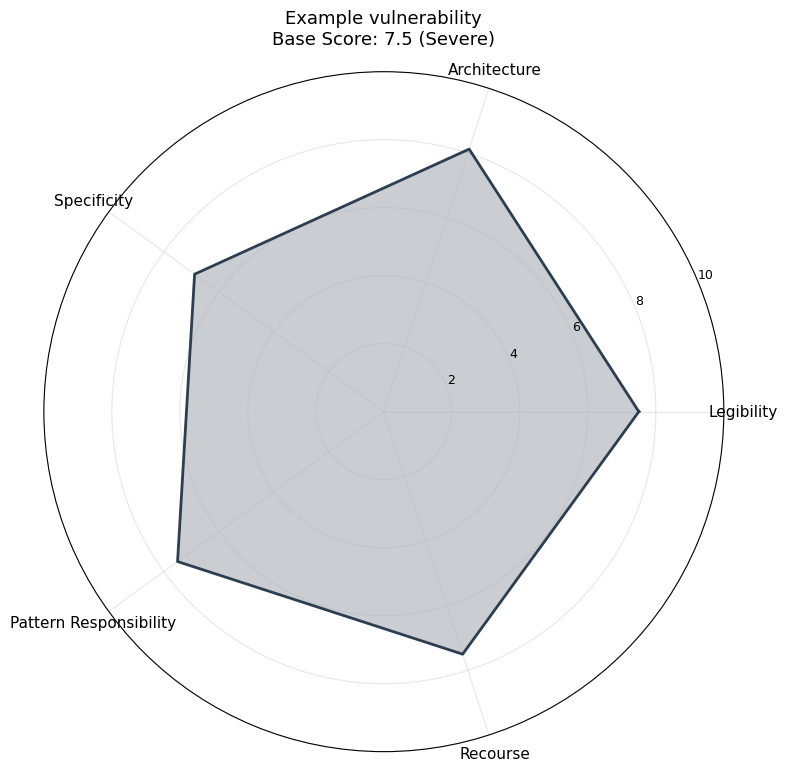

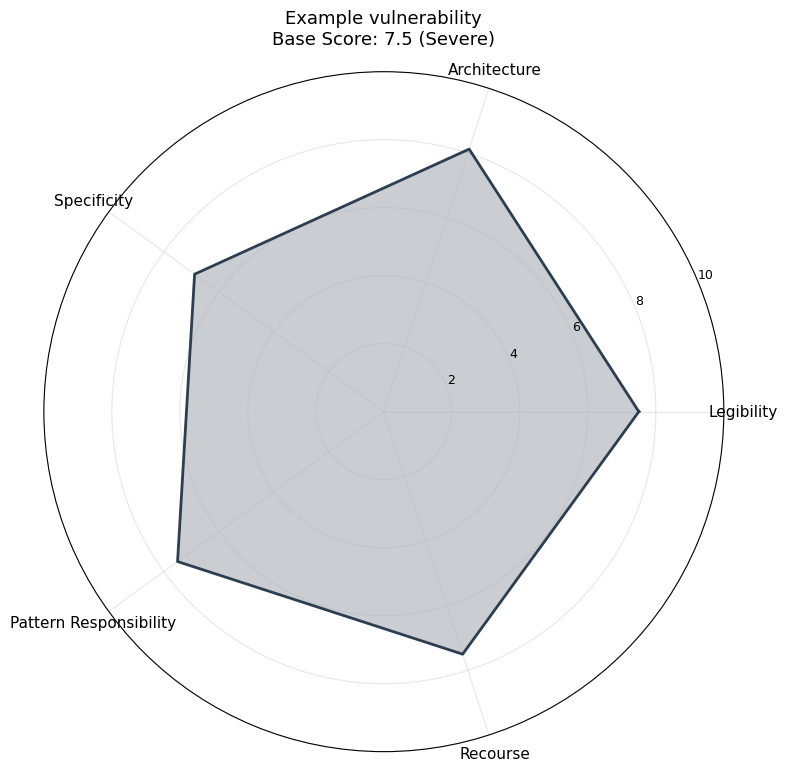

In [6]:
# Visualise the vulnerability as a radar chart
radar_chart(v)

In [7]:
# View the summary table
demo.summary_table()

,name,location,description,rationale,beneficiaries,cost_bearers,base_score,severity,legibility_score,architecture_score,specificity_score,pattern_responsibility_score,recourse_score
0,Example vulnerability,Section X of the demonstration regime,A short description of what this vulnerability...,A paragraph explaining the analyst's reasoning...,,,7.5,Severe,7.5,8.12,6.88,7.5,7.5


## What's next

You now have a working VMPD environment. The mechanics are simple:

1. Create a new analysis with `new_analysis()`
2. Add vulnerabilities with `analysis.add_vulnerability()`, providing the sub-metric scores and rationale
3. Visualise with `radar_chart()` or `comparison_chart()`
4. Generate a final report with `generate_report()`

The hard work is the diagnostic itself: identifying the vulnerabilities, scoring them honestly, and writing rationales that document your reasoning so others can engage with it.

**To do your own analysis:** copy `01_template_blank.ipynb`, rename it, and fill it in.

**To see a complete example:** look through `02_worked_example_pipeline_attestation.ipynb`.

---

*VMPD v1.0 — Bhavyatta Bhardwaj, 2026*